In [1]:
import casadi as ca
import numpy as np

In [2]:
def mean_casadi(data):
    return ca.sum1(data)/data.shape[0]

In [ ]:
S_init = 30e3/1000*np.ones(1000)

opti = ca.Opti()
S = opti.variable(1000)
obj = (-1)*ca.sum1( (10-0.005*np.linspace(1,1000,1000)) * 1e6 * ( 0.7 - 0.65/( 1+ca.exp((S-40)/8)) ) )
opti.minimize(obj)
opti.subject_to(S>=0)
opti.subject_to(ca.sum(S)==30e3)
opti.set_initial(S, S_init)

p_opts = {"expand":False,'verbose':0}
s_opts = {"print_level": 0}
opti.solver('fatrop',p_opts, s_opts)
sol = opti.solve()

      solver  :   t_proc      (avg)   t_wall      (avg)    n_eval
       nlp_f  |   6.00ms ( 26.79us)   9.71ms ( 43.37us)       224
       nlp_g  |   1.00ms ( 13.33us)   1.19ms ( 15.92us)        75
  nlp_grad_f  |   2.00ms ( 26.32us)   3.54ms ( 46.59us)        76
  nlp_hess_l  |   4.00ms ( 54.05us)   4.15ms ( 56.03us)        74
   nlp_jac_g  |   9.00ms (118.42us)   7.57ms ( 99.59us)        76
       total  |  46.42 s ( 46.42 s)  46.42 s ( 46.42 s)         1


In [4]:
print(sol.value(S))
print('Expected total return: ',sol.value(obj)/1e6,'Million $')


[ 5.75964545e+01  5.75914530e+01  5.75864483e+01  5.75814404e+01
  5.75764293e+01  5.75714150e+01  5.75663974e+01  5.75613767e+01
  5.75563526e+01  5.75513254e+01  5.75462949e+01  5.75412611e+01
  5.75362242e+01  5.75311839e+01  5.75261404e+01  5.75210936e+01
  5.75160436e+01  5.75109903e+01  5.75059337e+01  5.75008739e+01
  5.74958107e+01  5.74907443e+01  5.74856746e+01  5.74806016e+01
  5.74755253e+01  5.74704456e+01  5.74653627e+01  5.74602764e+01
  5.74551869e+01  5.74500940e+01  5.74449978e+01  5.74398982e+01
  5.74347953e+01  5.74296891e+01  5.74245795e+01  5.74194666e+01
  5.74143503e+01  5.74092306e+01  5.74041076e+01  5.73989813e+01
  5.73938515e+01  5.73887184e+01  5.73835819e+01  5.73784420e+01
  5.73732987e+01  5.73681520e+01  5.73630019e+01  5.73578484e+01
  5.73526915e+01  5.73475312e+01  5.73423675e+01  5.73372003e+01
  5.73320297e+01  5.73268557e+01  5.73216783e+01  5.73164974e+01
  5.73113130e+01  5.73061252e+01  5.73009340e+01  5.72957393e+01
  5.72905411e+01  5.72853

Text(0.5, 1.0, 'Optimal Investment Distribution')

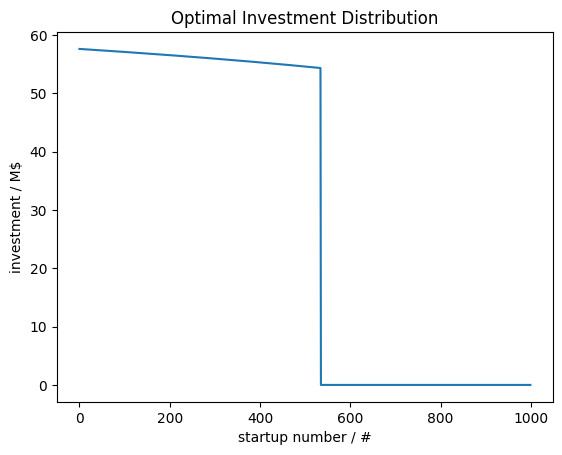

In [6]:
import matplotlib.pyplot as plt
plt.plot(sol.value(S))
plt.xlabel('startup number / #')
plt.ylabel('investment / M$')
plt.title('Optimal Investment Distribution')